In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pickle


current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


In [13]:
# colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']
# Wong (2011) colorblind-safe palette – 8 distinct colors
# Works for deuteranopia, protanopia, and tritanopia

# Grayscale palette – 10 shades from near-black to light gray
# Paired with distinct markers and line styles for full grayscale legibility
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown        
    '#006CD1',  # Cerulean     
]

colors = CB_COLORS

# Distinct markers and line styles for extra redundancy (grayscale-safe)
CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


In [14]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


##  Mean waveform

In [15]:
base    = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data"

In [16]:

# runs = {8.5: f'Run{120}',
#         7.5: f'Run{123}',
#         6.5: f'Run{127}',
#         5.5: f'Run{132}'
#         }

runs    = {8.5:f'Run{171}' 
           ,7.5:f'Run{173}'
           ,6.5:f'Run{175}'
           ,5.5:f'Run{177}'
           ,4.5:f'Run{179}'
           ,3.5:f'Run{181}'
           ,2.5:f'Run{183}'
           ,1.5:f'Run{185}'
           }

In [17]:
def compare_mean_waveforms(runs_dict, channels_to_show=None, invert=True, show_difference=False, logscale = True):
    """
    Compare mean waveforms from multiple runs
    
    Parameters:
    -----------
    runs_dict : dict
        Dictionary mapping labels (e.g., pressures) to run identifiers
        Example: {8.5: 'Run120', 7.5: 'Run123', 6.5: 'Run127'}
        or {8.5: 120, 7.5: 123, 6.5: 127}
    channels_to_show : list or None
        List of channel indices to plot. If None, plots all channels.
        Example: [0, 1] to show first two channels
    invert : bool
        If True, inverts the waveforms (multiply by -1)
    show_difference : bool
        If True and only 2 runs provided, plots the difference between them
    """
    # Convert run numbers to run names if needed
    runs_formatted = {}
    for label, run in runs_dict.items():
        if isinstance(run, int):
            runs_formatted[label] = f'Run{run}'
        else:
            runs_formatted[label] = run
    
    # Load data from all runs
    all_data = {}
    for label, run_name in runs_formatted.items():
        all_data[label] = np.load(f'{base}/mean_waveforms/mean_waveforms_{run_name}.npz', allow_pickle=True)
    
    # Get channels and time from first run
    first_label = list(runs_formatted.keys())[0]
    channels = all_data[first_label]['channels']
    
    # Determine which channels to plot
    if channels_to_show is None:
        channels_to_show = list(range(len(channels)))
    
    # Create subplots
    n_plots = len(channels_to_show)
    if n_plots > 1:
        fig, axs = plt.subplots(n_plots, 1, figsize=(16, n_plots*6), dpi=150, sharex=True)
        run_labels = ', '.join([f'{label} bar' for label in runs_formatted.keys()])
        axs[0].set_title(f'Comparison: {run_labels}')
    else:
        fig, ax = plt.subplots(1, 1, figsize=(16, 6), dpi=150)
        run_labels = ', '.join([f'{label} bar' for label in runs_formatted.keys()])
        ax.set_title(f'Comparison: {run_labels}')
    
    # Plot each channel
    for plot_idx, ch_idx in enumerate(channels_to_show):
        if n_plots > 1:
            ax = axs[plot_idx]
        
        # Store all waveforms for y-limit calculation
        all_waveforms = []
        
        # Plot waveform for each run
        for ii, (label, run_name) in enumerate(runs_formatted.items()):
            # Load mean waveform for this channel and run
            mean_waveform = all_data[label][f'ch_{channels[ch_idx]}']
            time = all_data[label]['time'] # <-- per-run time
            time_window = all_data[label]['time_window']

            # Invert if requested
            if invert:
                mean_waveform = -mean_waveform
            
            all_waveforms.append(mean_waveform)
            
            # Plot the waveform
            # ax.plot(time, mean_waveform, linewidth=3, label=f'{label} bar', color = colors[ii], alpha=0.7)
            # ax.plot(time, mean_waveform, linewidth=3, label=f'{label}', color = colors[ii], alpha=0.7)
            ax.plot(time, mean_waveform, 
                    linewidth=3, label=f'{label} bar', 
                    color = colors[ii], 
                    linestyle = CB_LINESTYLES[ii], 
                    # linestyle = '-', 
                    alpha=0.7)
            
            # ax.fill_between(time, 0, mean_waveform,
            #                 color  = colors[ii],
            #                 alpha  = 0.15,
            #                 zorder = 1)
        
        # Plot difference if only 2 runs and requested
        if show_difference and len(runs_formatted) == 2:
            labels = list(runs_formatted.keys())
            difference = all_waveforms[0] - all_waveforms[1]
            ax.plot(time, difference, linewidth=3, linestyle='--', 
                   label=f'Difference ({labels[0]} bar - {labels[1]} bar) ', 
                   alpha=0.4, color='red')
        
        # Calculate y limits for integration window
        y_min = min([wf.min() for wf in all_waveforms])
        y_max = max([wf.max() for wf in all_waveforms])*1.2
        
        # # Add integration window shading
        # ax.fill_between(time[time_window], 
        #                y_min, 
        #                y_max, 
        #                color='gray', alpha=0.15, label='integration window')
        
        # Add horizontal line at zero for reference
        ax.axhline(y=0, color='k', linestyle=':', alpha=0.3)
        
        ax.set_ylabel(f'ADC {channels[ch_idx]} [mV]')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize = font_size*0.7)
        if invert & logscale:
            y_min = min([wf[-1].min() for wf in all_waveforms])*0.5 # we zoom to include all the waveform
            ax.set_yscale('log')
        
            ax.set_ylim(y_min, y_max)
    
    if n_plots > 1:
        axs[-1].set_xlabel('Time (s)')
    else:
        ax.set_xlabel('Time (s)')
    
    plt.tight_layout()
    # plt.show()

    return fig, ax



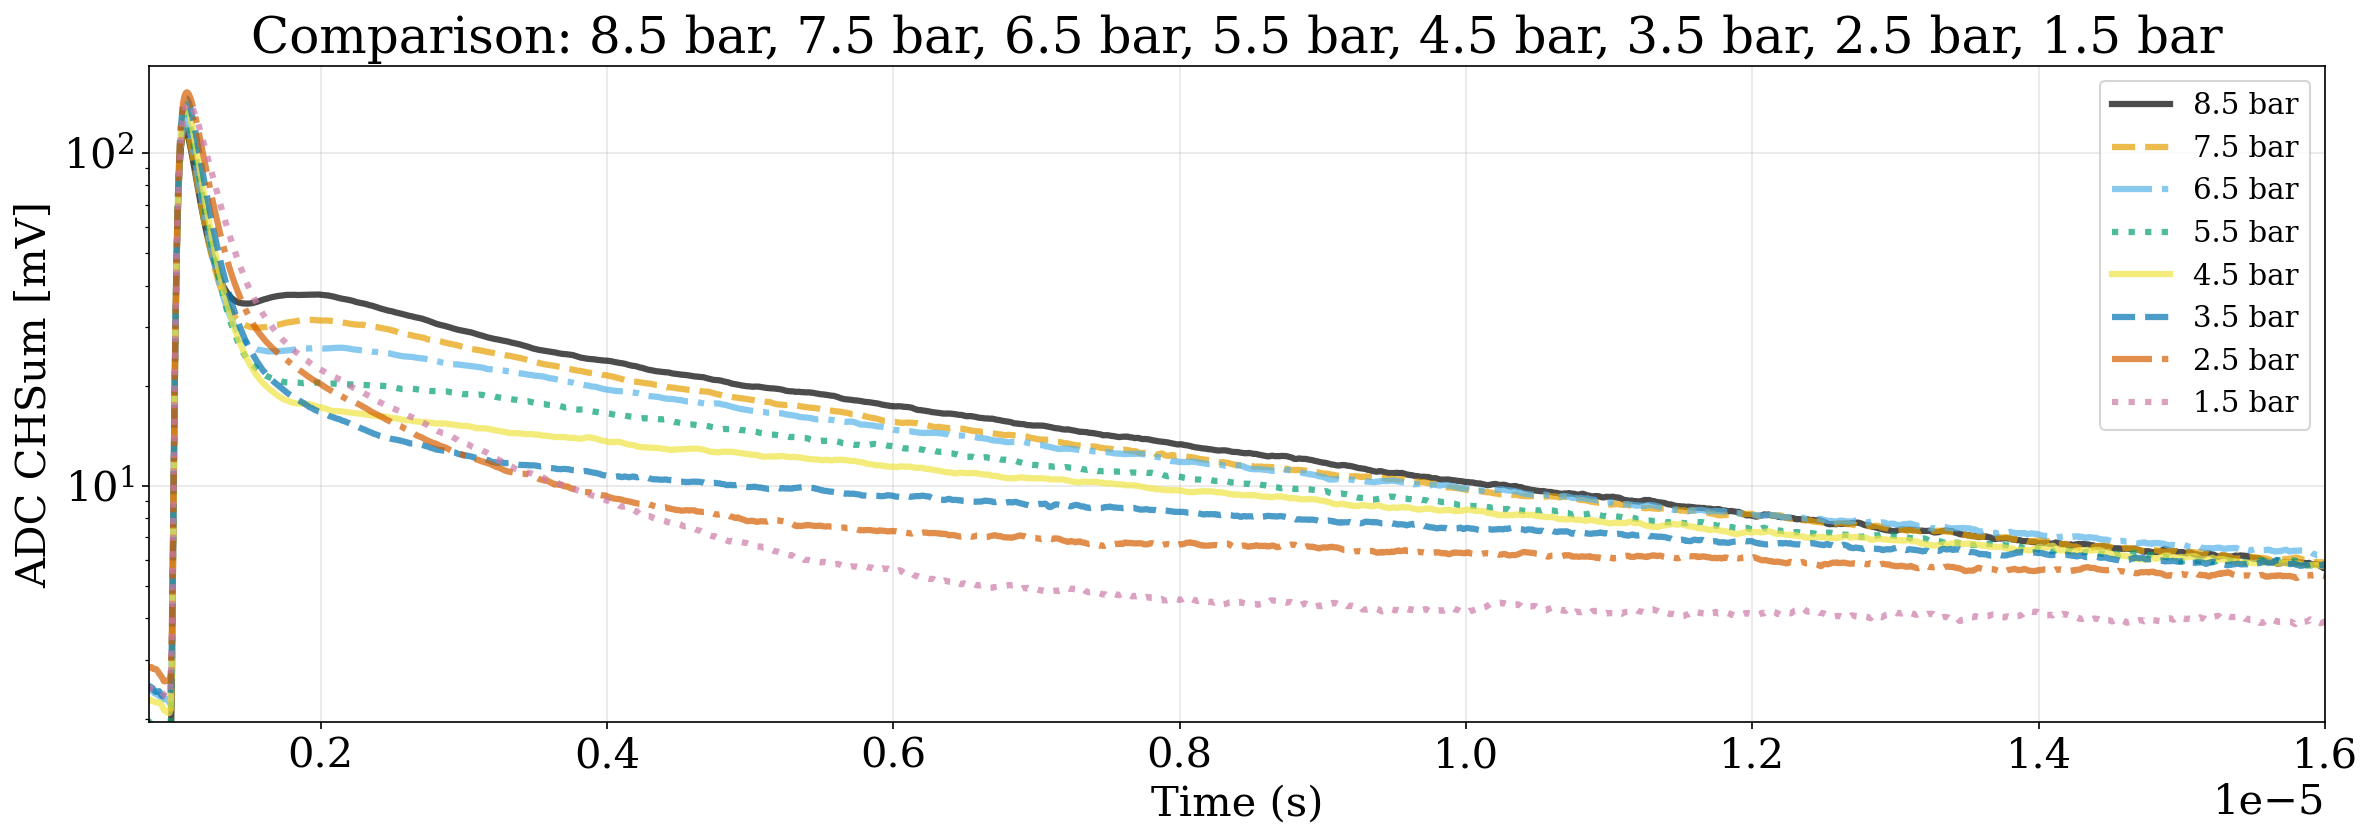

In [18]:

# Plot only CH1 (index 0), inverted, no difference
fig, ax = compare_mean_waveforms(runs, channels_to_show=[4], invert=True, show_difference=False)

# # Plot all channels, not inverted
# compare_mean_waveforms(runs, channels_to_show=None, invert=True, show_difference=False, logscale = True)

# With only 2 runs, you can show difference
# runs_2 = {'17/02 @ 9h50': f'Run{142}'
          # , '17/02 @ 10h50': f'Run{143}'
          # , '17/02 @ 11h50': f'Run{144}'
          # , '17/02 @ 12h10': f'Run{145}'
          # , '17/02 @ 12h30': f'Run{146}'
          # , '17/02 @ 12h50': f'Run{147}'
          # , '17/02 @ 15h25': f'Run{148}'
          # , '17/02 @ 16h15': f'Run{149}'
          # , '17/02 @ 16h45': f'Run{150}'
          # , '17/02 @ 17h15': f'Run{151}'
          # , '18/02 @ 10h35': f'Run{152}'
          # , '18/02 @ 12h20': f'Run{153}'
          # , '18/02 @ 17h40': f'Run{154}'
          # , '19/02 @ 11h55 (GAP OFF)': f'Run{155}'
          # , '19/02 @ 12h35': f'Run{156}'
          # , '19/02 @ 14h35 (CG OPEN)': f'Run{157}'
          # , '19/02 @ 15h35': f'Run{158}'
          # , '10/02 (Ar clean)': f'Run{132}'
          # }
# runs_2 = {'30/01 (Ar dirty @ 8.5bar)': 117
#           ,'10/02 (Ar clean)': 132
#           , '11/02 (Cold getter open: Xe contamination)': 133
#           # , '12/02 (After quick vacuum)': 135
#         #   , '12/02v2': 136
#         #   , '12/02v3': 137
#           # , '13/02 (After long vacuum)': 138
#           , '13/02 (Post-Sagardotegia)': 139
#           , '16/02': f'Run{140}'
#           }



# runs_2  = {#'30/01 (Ar dirty)': f'Run{117}'
#             # ,'03/02 (Ar clean)': f'Run{120}'
#             # ,'20/02 @ 10h45 (CG + GAP OFF)': f'Run{159}'
#             # ,'20/02 @ 12h25 ("")': f'Run{160}'
#             # ,'20/02 @ 14h45 ("")': f'Run{161}'
#             # ,'20/02 @ 15h25 ("")': f'Run{162}'
#             # ,'20/02 @ 16h35 ("")': f'Run{163}'
#             '23/02 @ 11h00 ("")': f'Run{164}'
#             # ,'23/02 @ 11h00 ("")': f'Run{164}'
#             # ,'23/02 @ 12h25 ("")': f'Run{165}'
#             ,'23/02 @ 14h15 ("")': f'Run{166}'
#             # ,'23/02 @ 15h30 ("")': f'Run{167}'
#             ,'23/02 @ 16h30 ("")': f'Run{168}'
#             # ,'23/02 @ 17h30 ("")': f'Run{169}'
#             ,'23/02 @ 18h30 ("")': f'Run{170}'
#             }

# # runs_2 = runs

# fig, ax = compare_mean_waveforms(runs_2, channels_to_show=[4], invert=True, show_difference=False, logscale = True)


# ax.set_xlim(100, 500)
ax.set_xlim(0.8e-6, 16e-6)
# ax.set_xlabel('Arbitrary units')
# ax.set_ylim(1e1, 1e2)

plt.show()